# Improved Doodle CNN Training for Kaggle
This notebook trains a CNN to classify drawings from the Quick Draw dataset. It is optimized for Kaggle's environment and GPU support.

### Instructions:
1. In Kaggle, add the dataset: **"Doodle Dataset"** by Ashish Jangra (`ashishjangra27/doodle-dataset`).
2. Enable **GPU T4 x2** (or any GPU) in the Notebook settings.
3. Run all cells.

In [1]:
import argparse
import ast
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import kagglehub

# Determine dataset path
KAGGLE_PATH = "/kaggle/input/doodle-dataset/master_doodle_dataframe.csv"
if os.path.exists(KAGGLE_PATH):
    DATASET_CSV = KAGGLE_PATH
    print(f"Found dataset at {DATASET_CSV}")
else:
    print("Kaggle path not found, downloading via kagglehub...")
    dataset_dir = kagglehub.dataset_download("ashishjangra27/doodle-dataset")
    DATASET_CSV = os.path.join(dataset_dir, "master_doodle_dataframe.csv")
    print(f"Dataset downloaded to {DATASET_CSV}")

Kaggle path not found, downloading via kagglehub...
Dataset downloaded to /kaggle/input/datasets/ashishjangra27/doodle-dataset/master_doodle_dataframe.csv


## Model Architecture

In [2]:
class ImprovedDoodleCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedDoodleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),    # 64x64 -> 32x32
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),    # 32x32 -> 16x16
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),    # 16x16 -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Data Preprocessing Utils

In [3]:
IMG_SIZE = 64

def strokes_to_image(strokes, size=(IMG_SIZE, IMG_SIZE)):
    """Convert stroke data to a grayscale image."""
    img = np.zeros(size, dtype=np.uint8)
    for stroke in strokes:
        if len(stroke) >= 2 and len(stroke[0]) > 0:
            for i in range(len(stroke[0]) - 1):
                x1 = int(min(stroke[0][i], size[1] - 1))
                y1 = int(min(stroke[1][i], size[0] - 1))
                x2 = int(min(stroke[0][i + 1], size[1] - 1))
                y2 = int(min(stroke[1][i + 1], size[0] - 1))
                cv2.line(img, (x1, y1), (x2, y2), 255, 2)
    return img

def load_and_prepare_data(csv_path, num_samples, min_samples_per_class=20):
    print("Loading dataset CSV...")
    df = pd.read_csv(csv_path)
    df = df[df['recognized'] == True]
    
    class_counts = df['word'].value_counts()
    valid_classes = class_counts[class_counts >= min_samples_per_class].index.tolist()
    df = df[df['word'].isin(valid_classes)]
    
    num_classes = len(valid_classes)
    print(f"  Classes with ≥{min_samples_per_class} samples: {num_classes}")
    
    samples_per_class = max(5, num_samples // num_classes)
    print(f"  Sampling {samples_per_class} per class ({samples_per_class * num_classes} total)...")
    
    sampled_dfs = []
    for word, group in df.groupby('word'):
        n = min(samples_per_class, len(group))
        if n < 5: continue
        sampled_dfs.append(group.sample(n=n, random_state=42))
    df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)
    
    class_names = sorted(df_sampled['word'].unique().tolist())
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    
    print(f"  Converting {len(df_sampled)} drawings to images...")
    images = []
    labels = []
    for _, row in tqdm(df_sampled.iterrows(), total=len(df_sampled)):
        try:
            strokes = ast.literal_eval(row['drawing'])
            img = strokes_to_image(strokes)
            images.append(img)
            labels.append(class_to_idx[row['word']])
        except: continue
    
    X = np.array(images, dtype=np.uint8).reshape(-1, 1, IMG_SIZE, IMG_SIZE)
    y = np.array(labels, dtype=np.int64)
    return X, y, class_names

## Augmentation

In [4]:
def augment_batch(images):
    device = images.device
    batch_size = images.size(0)
    augmented = images.clone()
    for i in range(batch_size):
        if torch.rand(1).item() > 0.5:
            angle = (torch.rand(1).item() - 0.5) * 30
            angle_rad = angle * np.pi / 180
            cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
            theta = torch.tensor([[cos_a, -sin_a, 0], [sin_a, cos_a, 0]], dtype=torch.float32, device=device).unsqueeze(0)
            grid = F.affine_grid(theta, augmented[i:i+1].size(), align_corners=False)
            augmented[i:i+1] = F.grid_sample(augmented[i:i+1], grid, align_corners=False)
        if torch.rand(1).item() > 0.5:
            tx = (torch.rand(1).item() - 0.5) * 0.2
            ty = (torch.rand(1).item() - 0.5) * 0.2
            theta = torch.tensor([[1, 0, tx], [0, 1, ty]], dtype=torch.float32, device=device).unsqueeze(0)
            grid = F.affine_grid(theta, augmented[i:i+1].size(), align_corners=False)
            augmented[i:i+1] = F.grid_sample(augmented[i:i+1], grid, align_corners=False)
    return augmented

## Training Functions

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(loader, desc="  Training", leave=False):
        inputs, labels = (inputs.to(device, dtype=torch.float32) / 255.0), labels.to(device)
        inputs = augment_batch(inputs)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = (inputs.to(device, dtype=torch.float32) / 255.0), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

## Main Training Loop

In [1]:
# SETTINGS
NUM_SAMPLES = 1000000 # Set high for better performance on Kaggle
EPOCHS = 50
BATCH_SIZE = 128
LR = 0.001
PATIENCE = 7
RESUME_FROM = "/kaggle/working/doodle_cnn_improved.pth" # Set to a path (e.g., "/kaggle/input/your-model/doodle_cnn_improved.pth") to resume training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X, y, class_names = load_and_prepare_data(DATASET_CSV, NUM_SAMPLES)
num_classes = len(class_names)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=BATCH_SIZE, shuffle=False)

model = ImprovedDoodleCNN(num_classes).to(device)

if RESUME_FROM and os.path.exists(RESUME_FROM):
    print(f"Loading weights from {RESUME_FROM}...")
    model.load_state_dict(torch.load(RESUME_FROM, map_location=device, weights_only=True))
    print("✅ Weights loaded successfully.")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = validate(model, val_loader, criterion, device)
    scheduler.step(v_loss)
    
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")
    
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "doodle_cnn_improved.pth")
        print("  ✅ Saved new best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

with open("class_names.txt", "w") as f:
    f.write("\n".join(class_names))
print("Training complete.")

Using device: cuda
Loading dataset CSV...
  Classes with ≥20 samples: 340
  Sampling 2941 per class (999940 total)...
  Converting 999940 drawings to images...


  0%|          | 0/999940 [00:00<?, ?it/s]

Loading weights from /kaggle/working/doodle_cnn_improved.pth...
✅ Weights loaded successfully.


  Training:   0%|          | 0/7031 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 4.5509 Acc: 0.1023 | Val Loss: 4.2673 Acc: 0.1350
  ✅ Saved new best model


...

Epoch 40/50 | Train Loss: 4.4795 Acc: 0.1102 | Val Loss: 4.2152 Acc: 0.1410


  Training:   0%|          | 0/7031 [00:00<?, ?it/s]

Epoch 41/50 | Train Loss: 4.4807 Acc: 0.1102 | Val Loss: 4.2156 Acc: 0.1411


  Training:   0%|          | 0/7031 [00:00<?, ?it/s]

Epoch 42/50 | Train Loss: 4.4797 Acc: 0.1101 | Val Loss: 4.2161 Acc: 0.1413
Early stopping at epoch 42
Training complete.


## Results Visualization

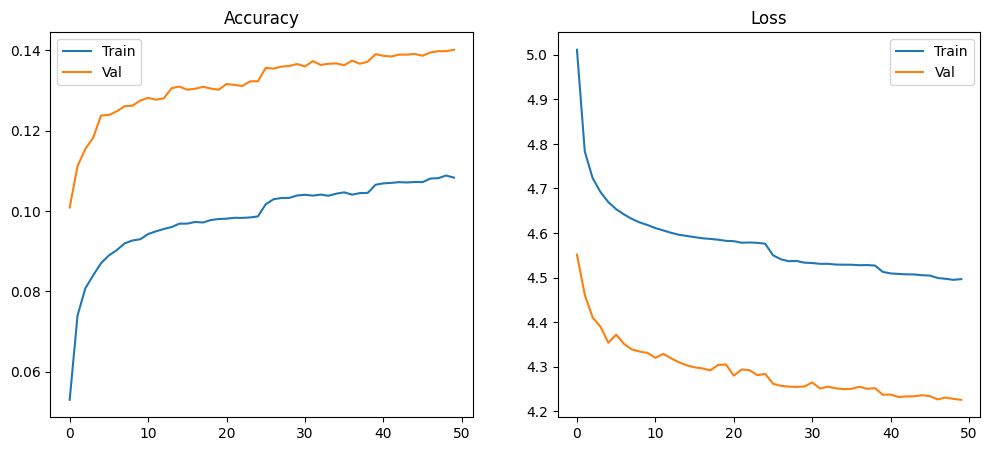

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()